# FIGURE 1 — VITESSES EN SITE (v_mean) EN FONCTION DE l

*(cellule indépendante : librairies, chemin, filtres et données rechargés ici)*

In [ ]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
from pathlib import Path

plt.rcParams['font.size'] = 16

# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────
root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/COMPACTION__PSMN__2026-04-30")
paths = [str(p) for p in root.rglob("*.parquet")]               # root + all levels of depth

# ─────────────────────────────────────────────
# PARAMETRES DE FILTRAGE
# ─────────────────────────────────────────────
mu    = 150
theta = 100
s_selected = 35

alphad_periodic = 0.0    # PERIODIC
alphad_homogen  = 1.0    # HOMOGEN (= periodic avec alphad = 1.0)
bpmin_random    = 0      # RANDOM

# ─────────────────────────────────────────────
# CHARGEMENT DES DONNEES
# ─────────────────────────────────────────────
ARRAY_COLS = ["results", "results_mean", "alpha_mean_a"]

df_data = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu)    &
        (pl.col("theta") == theta) &
        (pl.col("s")     == s_selected)
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS))
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)

# ─────────────────────────────────────────────
# SOUS-ENSEMBLES : PERIODIC / HOMOGEN / RANDOM
#
# NB : alphad est un flottant lu depuis du parquet -> sa représentation
# binaire n'est pas exactement 0.30 (ex : 0.29999999999999993 ou
# 0.30000000000000004). On arrondit donc à 3 décimales avant de filtrer,
# pour ne JAMAIS comparer deux floats avec une égalité stricte non protégée.
# ─────────────────────────────────────────────
df_periodic = (
    df_data
    .filter(pl.col("land") == "periodic")
    .with_columns(pl.col("alphad").round(3))
    .filter(pl.col("alphad") == alphad_periodic)
)

df_homogen = (
    df_data
    .filter(pl.col("land") == "periodic")
    .with_columns(pl.col("alphad").round(3))
    .filter(pl.col("alphad") == alphad_homogen)
)

df_random = (
    df_data
    .filter(pl.col("land") == "random")
    .with_columns(pl.col("bpmin").round(3))
    .filter(pl.col("bpmin") == bpmin_random)
)

def density(l):
    return (150 + l) / (35 + l)

# ─────────────────────────────────────────────
# FIGURE - VITESSES EN SITE (v_mean vs l)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6), dpi=1200)

# PERIODIC (alphad = 0)
l_periodic = df_periodic["l"].to_numpy()
v_periodic = df_periodic["v_mean"].to_numpy()
ax.plot(l_periodic, v_periodic, ls="-", alpha=0.75, label="Periodic")

# RANDOM (bpmin = 0)
l_random = df_random["l"].to_numpy()
v_random = df_random["v_mean"].to_numpy()
ax.plot(l_random, v_random, ls="-", alpha=0.75, label="Random")

# HOMOGEN (alphad = 1.0, equivalent periodique homogene)
l_homogen = df_homogen["l"].to_numpy()
v_homogen = mu / density(l_homogen)
ax.plot(l_homogen, v_homogen, ls="-", alpha=0.75, label="Homogen")

ax.axhline(mu, c="k", ls="--", label=r"$v=\mu$")

ax.set_xlabel(r"$<l>$")
ax.set_ylabel(r"$v_{mean}$")
ax.legend(loc="best")
ax.grid(True, alpha=0.30, which="both")

plt.tight_layout()
plt.show()


# FIGURE 2 — COMPACTION EN FONCTION DE l_mean

*(cellule indépendante)*

In [ ]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 16

def density(l):
    return (150 + l) / (35 + l)

# ─────────────────────────────────────────────
# FIGURE - COMPACTION vs l_mean
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6), dpi=1200)

l_mean = np.arange(0, 500, 1)
ax.plot(l_mean, density(l_mean), ls="-", alpha=1)

ax.set_xlabel(r"$<l>$")
ax.set_ylabel(r"$\overline{c}$")
ax.grid(True, alpha=0.30)

plt.tight_layout()
plt.show()


# FIGURE 5.C

*(cellule indépendante — alphad = 0.30 affiché correctement malgré l'imprécision binaire des flottants)*

In [ ]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
import numpy as np
from pathlib import Path

plt.rcParams['font.size'] = 16

# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────
root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/COMPACTION__PSMN__2026-04-30")
paths = [str(p) for p in root.rglob("*.parquet")]               # root + all levels of depth

# ─────────────────────────────────────────────
# PARAMETRES DE FILTRAGE
# ─────────────────────────────────────────────
mu    = 150
theta = 100

# ─────────────────────────────────────────────
# CHARGEMENT DES DONNEES
# ─────────────────────────────────────────────
ARRAY_COLS = []

df_data = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu) &
        (pl.col("theta") == theta)
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS))
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)

df_periodic = df_data.filter(pl.col("land") == "periodic")
df_random   = df_data.filter(pl.col("land") == "random")

# ─────────────────────────────────────────────
# FIGURE - 5.C
# ─────────────────────────────────────────────
v_to_plot = "vc_mean"

fig, ax = plt.subplots(figsize=(8, 6), dpi=1200)

# Valeurs cibles d'alphad / bpmin à tracer.
alphads_target = np.array([0.0, 0.30])
bpmins_target  = np.array([0, 20])

# ── Main ──────────────────────────────────────
#
# IMPORTANT : alphad est un flottant lu depuis du parquet. 0.30 n'a pas de
# représentation binaire exacte (il vaut en mémoire un truc du type
# 0.29999999999999998889776975... ou 0.30000000000000004440892...).
# Une comparaison stricte `alphad in alphads_target` peut donc échouer en
# silence et faire disparaître la courbe correspondante, alors qu'on a bien
# les bonnes données en base. On compare ici avec une tolérance (np.isclose)
# et on affiche le label arrondi à 2 décimales pour garantir un "0.30"
# propre dans la légende.

for group in df_periodic.partition_by("alphad", as_dict=False):
    alphad = group["alphad"][0]
    l_mean = group["l_mean"].to_numpy()
    vc     = group[v_to_plot].to_numpy()
    if np.any(np.isclose(alphad, alphads_target, atol=1e-6)):
        ax.plot(l_mean, vc, marker="s", ls="-", alpha=0.75,
                 label=f"Periodic : alphad = {alphad:.2f}")

for group in df_random.partition_by("bpmin", as_dict=False):
    bpmin  = group["bpmin"][0]
    l_mean = group["l"].to_numpy()
    vc     = group[v_to_plot].to_numpy()
    if np.any(np.isclose(bpmin, bpmins_target, atol=1e-6)):
        ax.plot(l_mean, vc, marker="o", ls="-", alpha=0.75,
                 label=f"Random : bpmin = {bpmin}")

ax.axhline(mu, c="k", ls="--", label=r"$v = \mu * \overline{c}$")
ax.set_xlim([0, 500])
ax.set_xlabel(r"$<l>$")
ax.set_ylabel(r"$v^{bp}_{mean}$")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.30)
plt.tight_layout()
plt.show()


# FIGURE RECAPITULATIVE — FIG.1 / FIG.2 (gauche) + FIG.5.C (droite)

*(cellule indépendante — pur affichage : mêmes données, mêmes courbes, même taille de police partout)*

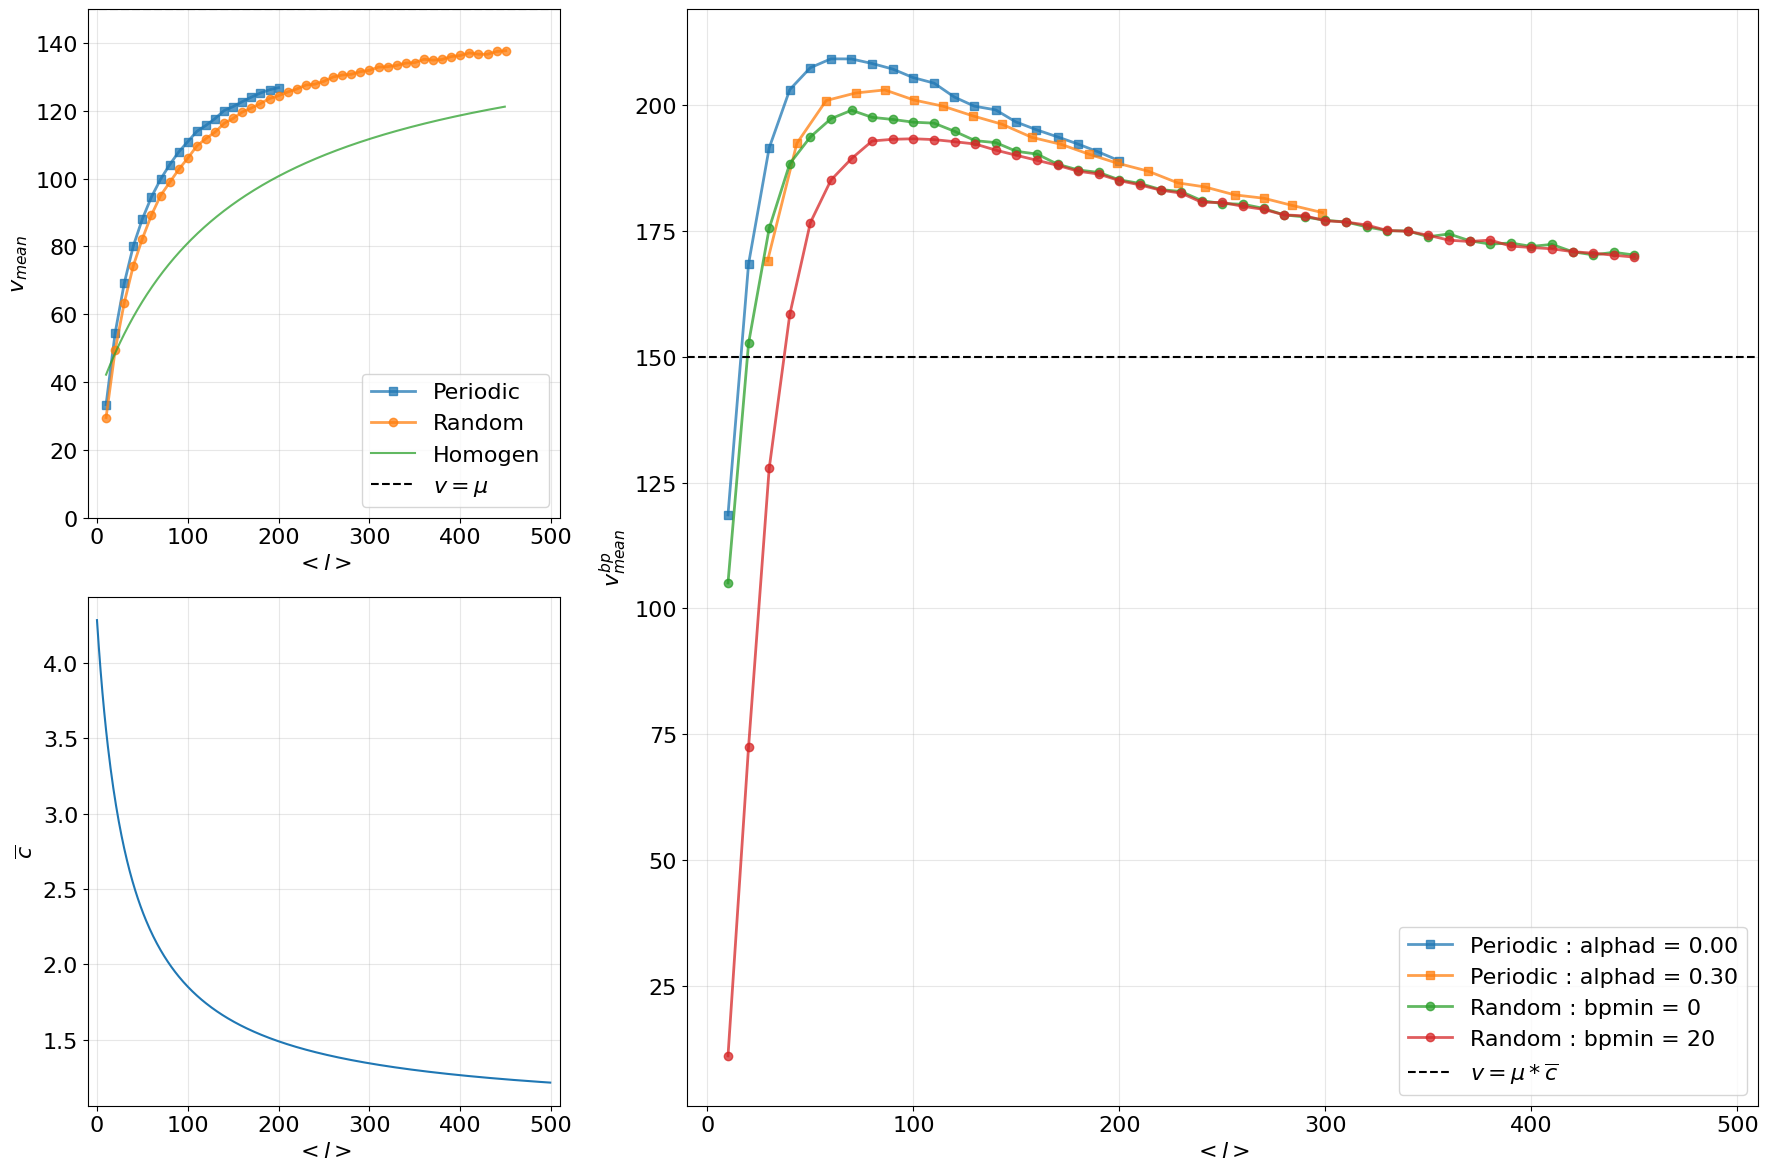

In [20]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
import numpy as np
from pathlib import Path

# Taille de police UNIQUE pour toute la figure (titres, labels, ticks,
# legendes) : on garde exactement la même valeur que dans les figures
# individuelles, donc rien n'est redéfini case par case ci-dessous.
plt.rcParams['font.size'] = 16

# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────
root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/COMPACTION__PSMN__2026-04-30")
paths = [str(p) for p in root.rglob("*.parquet")]               # root + all levels of depth

# ─────────────────────────────────────────────
# PARAMETRES DE FILTRAGE
# ─────────────────────────────────────────────
mu    = 150
theta = 100
s_selected = 35

alphad_periodic = 0.0    # PERIODIC
alphad_homogen  = 1.0    # HOMOGEN (= periodic avec alphad = 1.0)
bpmin_random    = 0      # RANDOM

xlims=[-10, 510]

def density(l):
    return (150 + l) / (35 + l)

# ─────────────────────────────────────────────
# DONNEES POUR FIG.1 ET FIG.2 (filtre sur s_selected)
# ─────────────────────────────────────────────
ARRAY_COLS_12 = ["results", "results_mean", "alpha_mean_a"]

df_data_12 = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu)    &
        (pl.col("theta") == theta) &
        (pl.col("s")     == s_selected)
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS_12))
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)

# NB : alphad/bpmin sont des flottants issus de parquet -> on arrondit avant
# de filtrer pour ne jamais comparer deux floats avec une égalité stricte
# non protégée (cf. figures précédentes).
df_periodic_12 = (
    df_data_12
    .filter(pl.col("land") == "periodic")
    .with_columns(pl.col("alphad").round(3))
    .filter(pl.col("alphad") == alphad_periodic)
)

df_homogen_12 = (
    df_data_12
    .filter(pl.col("land") == "periodic")
    .with_columns(pl.col("alphad").round(3))
    .filter(pl.col("alphad") == alphad_homogen)
)

df_random_12 = (
    df_data_12
    .filter(pl.col("land") == "random")
    .with_columns(pl.col("bpmin").round(3))
    .filter(pl.col("bpmin") == bpmin_random)
)

# ─────────────────────────────────────────────
# DONNEES POUR FIG.5.C (pas de filtre sur s)
# ─────────────────────────────────────────────
df_data_5c = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu) &
        (pl.col("theta") == theta)
    )
    .select(cs.numeric() | cs.boolean() | cs.string())
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)

df_periodic_5c = df_data_5c.filter(pl.col("land") == "periodic")
df_random_5c   = df_data_5c.filter(pl.col("land") == "random")

v_to_plot      = "vc_mean"
alphads_target = np.array([0.0, 0.30])
bpmins_target  = np.array([0, 20])

# ─────────────────────────────────────────────
# MISE EN PAGE : grille 2x2
#   - FIG.1 -> en haut a gauche
#   - FIG.2 -> en bas a gauche
#   - FIG.5.C -> a droite, sur les 2 lignes (donc 2 carres de haut)
# Resultat : 2 carres empiles a gauche + 1 grand carre/rectangle a droite.
# Chaque sous-figure garde le meme rapport largeur/hauteur qu'un carre
# individuel (8x6 -> ici 8x8 pour rester proche d'un carre), et la taille
# de police est identique partout puisqu'on ne touche a aucun fontsize
# local : tout vient du rcParams global defini plus haut.
# ─────────────────────────────────────────────


fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, 1],
    height_ratios=[1, 1]
)

ax1 = fig.add_subplot(gs[0, 0])      # Fig.1
ax2 = fig.add_subplot(gs[1, 0])      # Fig.2
ax3 = fig.add_subplot(gs[:, 1:])     # grand carré (2 colonnes × 2 lignes)

# ── FIG.1 : VITESSES EN SITE (v_mean vs l) ─────
l_periodic = df_periodic_12["l"].to_numpy()
v_periodic = df_periodic_12["v_mean"].to_numpy()
ax1.plot(l_periodic, v_periodic, ls="-", lw=2, alpha=0.75, marker="s", label="Periodic")

l_random = df_random_12["l"].to_numpy()
v_random = df_random_12["v_mean"].to_numpy()
ax1.plot(l_random, v_random, ls="-", lw=2, alpha=0.75, marker="o", label="Random")

l_homogen = np.arange(10,450,1)
v_homogen = mu / density(l_homogen)
ax1.plot(l_homogen, v_homogen, ls="-", alpha=0.75, label="Homogen")

ax1.axhline(mu, c="k", ls="--", label=r"$v=\mu$")
ax1.set_xlabel(r"$<l>$")
ax1.set_ylabel(r"$v_{mean}$")
ax1.set_xlim(xlims)
ax1.set_ylim([0,150])
ax1.legend(loc="best")
ax1.grid(True, alpha=0.30, which="both")

# ── FIG.2 : COMPACTION vs l_mean ───────────────
l_mean_curve = np.arange(0, 500, 1)
ax2.plot(l_mean_curve, density(l_mean_curve), ls="-", alpha=1)
ax2.set_xlabel(r"$<l>$")
ax2.set_ylabel(r"$\overline{c}$")
ax2.set_xlim(xlims)
ax2.grid(True, alpha=0.30)

# ── FIG.5.C ─────────────────────────────────────
for group in df_periodic_5c.partition_by("alphad", as_dict=False):
    alphad = group["alphad"][0]
    l_mean = group["l_mean"].to_numpy()
    vc     = group[v_to_plot].to_numpy()
    if np.any(np.isclose(alphad, alphads_target, atol=1e-6)):
        ax3.plot(l_mean, vc, ls="-", lw=2, alpha=0.75, marker="s",
                  label=f"Periodic : alphad = {alphad:.2f}")

for group in df_random_5c.partition_by("bpmin", as_dict=False):
    bpmin  = group["bpmin"][0]
    l_mean = group["l"].to_numpy()
    vc     = group[v_to_plot].to_numpy()
    if np.any(np.isclose(bpmin, bpmins_target, atol=1e-6)):
        ax3.plot(l_mean, vc, ls="-", lw=2, alpha=0.75, marker="o",
                  label=f"Random : bpmin = {bpmin}")

ax3.axhline(mu, c="k", ls="--", label=r"$v = \mu * \overline{c}$")
ax3.set_xlim([0, 500])
ax3.set_xlabel(r"$<l>$")
ax3.set_ylabel(r"$v^{bp}_{mean}$")
ax3.legend(loc="lower right")
ax3.set_xlim(xlims)
ax3.grid(True, alpha=0.30)

plt.tight_layout()
plt.savefig("fig5.png")
plt.show()

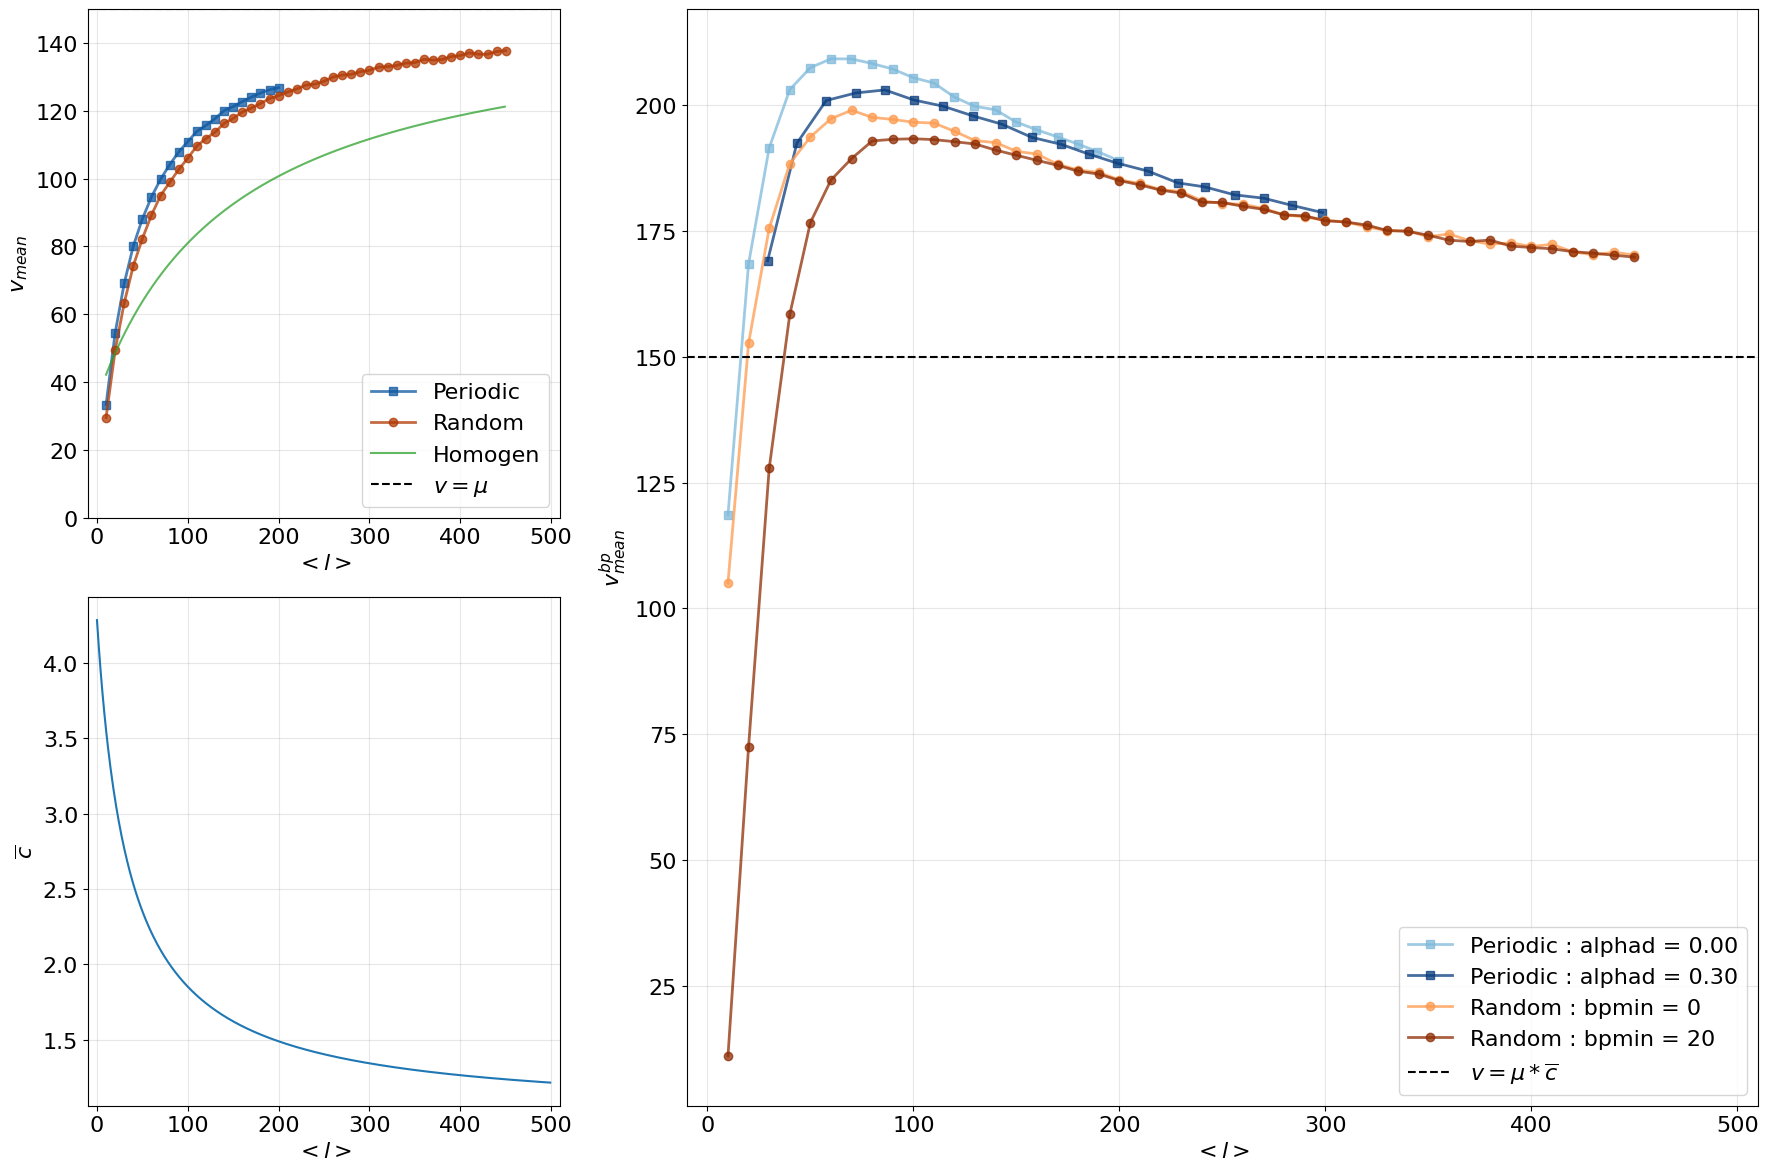

In [23]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
import numpy as np
from pathlib import Path

# Taille de police UNIQUE pour toute la figure (titres, labels, ticks,
# legendes) : on garde exactement la même valeur que dans les figures
# individuelles, donc rien n'est redéfini case par case ci-dessous.
plt.rcParams['font.size'] = 16

# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────
root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/COMPACTION__PSMN__2026-04-30")
paths = [str(p) for p in root.rglob("*.parquet")]               # root + all levels of depth

# ─────────────────────────────────────────────
# PARAMETRES DE FILTRAGE
# ─────────────────────────────────────────────
mu    = 150
theta = 100
s_selected = 35

alphad_periodic = 0.0    # PERIODIC
alphad_homogen  = 1.0    # HOMOGEN (= periodic avec alphad = 1.0)
bpmin_random    = 0      # RANDOM

xlims=[-10, 510]

def density(l):
    return (150 + l) / (35 + l)

# ─────────────────────────────────────────────
# COULEURS COHERENTES ENTRE LES SOUS-FIGURES
# ─────────────────────────────────────────────
# Objectif : la FAMILLE (Periodic vs Random) porte la meme teinte en haut
# a gauche (ax1) et a droite (ax3), sans rien changer au reste du code
# (memes donnees, memes filtres, memes labels, meme mise en page).
# On fixe donc explicitement les couleurs au lieu de laisser matplotlib
# les attribuer automatiquement via le cycle par defaut (ce qui les
# desynchronise entre ax1 et ax3 puisque ax3 contient davantage de
# courbes que ax1).
#
# A droite (ax3), chaque famille comporte en plus PLUSIEURS variantes
# (alphad pour Periodic, bpmin pour Random) qui doivent rester
# visuellement distinguables : on degrade donc la teinte (clair -> fonce)
# selon la variante, via deux colormaps dedies (Blues pour Periodic,
# Oranges pour Random). Pour ax1, qui n'affiche qu'une seule courbe par
# famille, on reutilise la nuance la plus foncee de chaque colormap.
cmap_periodic = plt.cm.Blues
cmap_random   = plt.cm.Oranges
color_homogen = "tab:green"

color_periodic = cmap_periodic(0.85)   # nuance "principale" utilisee dans ax1
color_random   = cmap_random(0.85)     # nuance "principale" utilisee dans ax1

# Nuances utilisees a droite (ax3), une par variante, du plus clair (premiere
# valeur de la liste cible) au plus fonce (derniere valeur de la liste cible).
shades_periodic = [cmap_periodic(x) for x in np.linspace(0.45, 0.95, len(alphads_target))]
shades_random   = [cmap_random(x)   for x in np.linspace(0.45, 0.95, len(bpmins_target))]

# ─────────────────────────────────────────────
# DONNEES POUR FIG.1 ET FIG.2 (filtre sur s_selected)
# ─────────────────────────────────────────────
ARRAY_COLS_12 = ["results", "results_mean", "alpha_mean_a"]

df_data_12 = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu)    &
        (pl.col("theta") == theta) &
        (pl.col("s")     == s_selected)
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS_12))
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)

# NB : alphad/bpmin sont des flottants issus de parquet -> on arrondit avant
# de filtrer pour ne jamais comparer deux floats avec une égalité stricte
# non protégée (cf. figures précédentes).
df_periodic_12 = (
    df_data_12
    .filter(pl.col("land") == "periodic")
    .with_columns(pl.col("alphad").round(3))
    .filter(pl.col("alphad") == alphad_periodic)
)

df_homogen_12 = (
    df_data_12
    .filter(pl.col("land") == "periodic")
    .with_columns(pl.col("alphad").round(3))
    .filter(pl.col("alphad") == alphad_homogen)
)

df_random_12 = (
    df_data_12
    .filter(pl.col("land") == "random")
    .with_columns(pl.col("bpmin").round(3))
    .filter(pl.col("bpmin") == bpmin_random)
)

# ─────────────────────────────────────────────
# DONNEES POUR FIG.5.C (pas de filtre sur s)
# ─────────────────────────────────────────────
df_data_5c = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu) &
        (pl.col("theta") == theta)
    )
    .select(cs.numeric() | cs.boolean() | cs.string())
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)

df_periodic_5c = df_data_5c.filter(pl.col("land") == "periodic")
df_random_5c   = df_data_5c.filter(pl.col("land") == "random")

v_to_plot      = "vc_mean"
alphads_target = np.array([0.0, 0.30])
bpmins_target  = np.array([0, 20])

# ─────────────────────────────────────────────
# MISE EN PAGE : grille 2x2
#   - FIG.1 -> en haut a gauche
#   - FIG.2 -> en bas a gauche
#   - FIG.5.C -> a droite, sur les 2 lignes (donc 2 carres de haut)
# Resultat : 2 carres empiles a gauche + 1 grand carre/rectangle a droite.
# Chaque sous-figure garde le meme rapport largeur/hauteur qu'un carre
# individuel (8x6 -> ici 8x8 pour rester proche d'un carre), et la taille
# de police est identique partout puisqu'on ne touche a aucun fontsize
# local : tout vient du rcParams global defini plus haut.
# ─────────────────────────────────────────────


fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, 1],
    height_ratios=[1, 1]
)

ax1 = fig.add_subplot(gs[0, 0])      # Fig.1
ax2 = fig.add_subplot(gs[1, 0])      # Fig.2
ax3 = fig.add_subplot(gs[:, 1:])     # grand carré (2 colonnes × 2 lignes)

# ── FIG.1 : VITESSES EN SITE (v_mean vs l) ─────
l_periodic = df_periodic_12["l"].to_numpy()
v_periodic = df_periodic_12["v_mean"].to_numpy()
ax1.plot(l_periodic, v_periodic, ls="-", lw=2, alpha=0.75, marker="s", label="Periodic", color=color_periodic)

l_random = df_random_12["l"].to_numpy()
v_random = df_random_12["v_mean"].to_numpy()
ax1.plot(l_random, v_random, ls="-", lw=2, alpha=0.75, marker="o", label="Random", color=color_random)

l_homogen = np.arange(10,450,1)
v_homogen = mu / density(l_homogen)
ax1.plot(l_homogen, v_homogen, ls="-", alpha=0.75, label="Homogen", color=color_homogen)

ax1.axhline(mu, c="k", ls="--", label=r"$v=\mu$")
ax1.set_xlabel(r"$<l>$")
ax1.set_ylabel(r"$v_{mean}$")
ax1.set_xlim(xlims)
ax1.set_ylim([0,150])
ax1.legend(loc="best")
ax1.grid(True, alpha=0.30, which="both")

# ── FIG.2 : COMPACTION vs l_mean ───────────────
l_mean_curve = np.arange(0, 500, 1)
ax2.plot(l_mean_curve, density(l_mean_curve), ls="-", alpha=1)
ax2.set_xlabel(r"$<l>$")
ax2.set_ylabel(r"$\overline{c}$")
ax2.set_xlim(xlims)
ax2.grid(True, alpha=0.30)

# ── FIG.5.C ─────────────────────────────────────
for group in df_periodic_5c.partition_by("alphad", as_dict=False):
    alphad = group["alphad"][0]
    l_mean = group["l_mean"].to_numpy()
    vc     = group[v_to_plot].to_numpy()
    match  = np.isclose(alphad, alphads_target, atol=1e-6)
    if np.any(match):
        idx = int(np.argmax(match))   # position de cette variante dans alphads_target -> nuance associee
        ax3.plot(l_mean, vc, ls="-", lw=2, alpha=0.75, marker="s",
                  label=f"Periodic : alphad = {alphad:.2f}", color=shades_periodic[idx])

for group in df_random_5c.partition_by("bpmin", as_dict=False):
    bpmin  = group["bpmin"][0]
    l_mean = group["l"].to_numpy()
    vc     = group[v_to_plot].to_numpy()
    match  = np.isclose(bpmin, bpmins_target, atol=1e-6)
    if np.any(match):
        idx = int(np.argmax(match))   # position de cette variante dans bpmins_target -> nuance associee
        ax3.plot(l_mean, vc, ls="-", lw=2, alpha=0.75, marker="o",
                  label=f"Random : bpmin = {bpmin}", color=shades_random[idx])

ax3.axhline(mu, c="k", ls="--", label=r"$v = \mu * \overline{c}$")
ax3.set_xlim([0, 500])
ax3.set_xlabel(r"$<l>$")
ax3.set_ylabel(r"$v^{bp}_{mean}$")
ax3.legend(loc="lower right")
ax3.set_xlim(xlims)
ax3.grid(True, alpha=0.30)

plt.tight_layout()
plt.savefig("fig5.png")
plt.show()

# .